In [1]:
# !pip install mlflow
# !pip install kagglehub
# !pip install tensorflow==2.14


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

2025-08-06 22:48:47.325667: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-06 22:48:47.361003: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
import kagglehub
import os
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Download FER2013 dataset from KaggleHub
path = kagglehub.dataset_download("msambare/fer2013")
print("Path to dataset files:", path)

Path to dataset files: /home/pattinson/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [4]:
# The dataset will be inside something like: /.../msambare/fer2013/<version>/
# Locate the image directory assuming it's extracted like:
train_path = os.path.join(path, "train")
val_path = os.path.join(path, "test")

In [5]:
# Confirm structure
print("Train path:", train_path)
print("Validation path:", val_path)

Train path: /home/pattinson/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train
Validation path: /home/pattinson/.cache/kagglehub/datasets/msambare/fer2013/versions/1/test


In [6]:
# Initialize MLflow experiment
mlflow.set_experiment("Diabetes_Prediction")

<Experiment: artifact_location='file:///mnt/d/ConestogaCollegeWorkplaceLevel2/INFO8665-ProjectML/INFO8665-ProjectML-Moosic/training/mlruns/965856356120480661', creation_time=1754532158892, experiment_id='965856356120480661', last_update_time=1754532158892, lifecycle_stage='active', name='Diabetes_Prediction', tags={}>

In [7]:
# Image settings
IMG_HEIGHT, IMG_WIDTH = 48, 48
BATCH_SIZE = 64

In [8]:
# Load data using ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Define model
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(48, 48, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')  # FER2013 has 7 emotion classes
])

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

model.summary()


/home/pattinson/.pyenv/versions/3.12.9/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,473,863 (9.44 MB)

 Trainable params: 2,472,967 (9.43 MB)

 Non-trainable params: 896 (3.50 KB)

In [10]:
# Train model
EPOCHS = 10 # Train model
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

# Make predictions
y_pred = model.predict(val_generator)

# calculate metrics
y_pred_classes = y_pred.argmax(axis=1)
y_true = val_generator.classes
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

# save model and metrics to mlflow
with mlflow.start_run():
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.sklearn.log_model(model, "emotion_recognition_model")


/home/pattinson/.pyenv/versions/3.12.9/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 73s 159ms/step - accuracy: 0.2549 - loss: 2.2158 - val_accuracy: 0.3583 - val_loss: 1.7097
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 69s 154ms/step - accuracy: 0.3366 - loss: 1.6862 - val_accuracy: 0.4075 - val_loss: 1.5075
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 71s 158ms/step - accuracy: 0.3727 - loss: 1.6053 - val_accuracy: 0.4450 - val_loss: 1.4494
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 70s 155ms/step - accuracy: 0.3984 - loss: 1.5488 - val_accuracy: 0.4521 - val_loss: 1.4099
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 71s 158ms/step - accuracy: 0.4246 - loss: 1.5014 - val_accuracy: 0.4759 - val_loss: 1.3686
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 72s 160ms/step - accuracy: 0.4401 - loss: 1.4631 - val_accuracy: 0.4354 - val_loss: 1.4430
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 72s 160ms/step - accuracy: 0.4562 - loss: 1.4177 - val_accuracy: 0.5006 - val_loss: 1.3038
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 70s 156ms/step - accuracy: 0.4662 - loss: 1

/home/pattinson/.pyenv/versions/3.12.9/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2025/08/06 23:00:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/06 23:00:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [18]:
# !mlflow ui

[2025-08-06 23:04:04 -0400] [54870] [INFO] Starting gunicorn 23.0.0
[2025-08-06 23:04:04 -0400] [54870] [INFO] Listening at: http://127.0.0.1:5000 (54870)
[2025-08-06 23:04:04 -0400] [54870] [INFO] Using worker: sync
[2025-08-06 23:04:04 -0400] [54877] [INFO] Booting worker with pid: 54877
[2025-08-06 23:04:04 -0400] [54879] [INFO] Booting worker with pid: 54879
[2025-08-06 23:04:04 -0400] [54880] [INFO] Booting worker with pid: 54880
[2025-08-06 23:04:04 -0400] [54881] [INFO] Booting worker with pid: 54881
[2025-08-06 23:18:17 -0400] [54870] [INFO] Handling signal: int
^C

Aborted!
[2025-08-06 23:18:17 -0400] [54879] [INFO] Worker exiting (pid: 54879)
[2025-08-06 23:18:17 -0400] [54877] [INFO] Worker exiting (pid: 54877)
[2025-08-06 23:18:17 -0400] [54881] [INFO] Worker exiting (pid: 54881)
[2025-08-06 23:18:17 -0400] [54880] [INFO] Worker exiting (pid: 54880)


In [11]:
# Save the model
model.save("fer2013_emotion_recognition_model.h5")

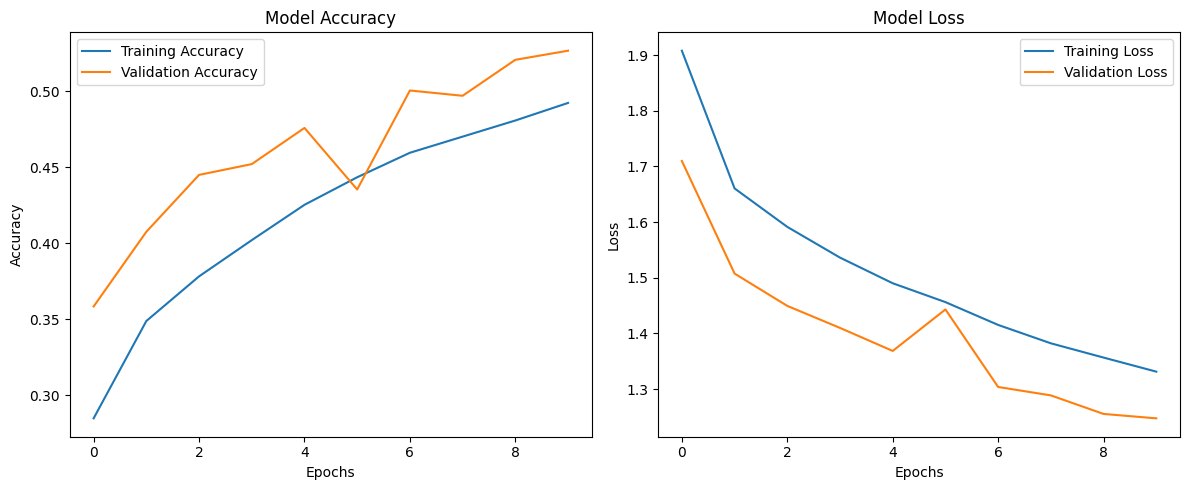

In [12]:
#Plot the training history
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [13]:
#Load the model later using:
from tensorflow.keras.models import load_model

model = load_model("fer2013_emotion_recognition_model.h5")

# Evaluate the model
score = model.evaluate(val_generator)
print("Validation Loss:", score[0])
print("Validation Accuracy:", score[1])


113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5312 - loss: 1.2333
Validation Loss: 1.247471809387207
Validation Accuracy: 0.5267484188079834


---

MobileNet

In [14]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os

# === CONFIG ===
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
NUM_CLASSES = 7  # FER2013 has 7 emotion classes
EPOCHS_FROZEN = 20
EPOCHS_FINE = 10

train_path = os.path.join(path, "train")
val_path = os.path.join(path, "test")


In [15]:
# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    rotation_range=25,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Helper function for RGB loading
def rgb_flow_from_directory(datagen, path):
    return datagen.flow_from_directory(
        path,
        target_size=IMG_SIZE,
        color_mode='rgb',   # Converts grayscale images to RGB
        class_mode='categorical',
        batch_size=BATCH_SIZE,
        shuffle=True
    )

# Create generators
train_gen = rgb_flow_from_directory(train_datagen, train_path)
val_gen = rgb_flow_from_directory(val_datagen, val_path)

# Check class mapping
print("Class index mapping:", train_gen.class_indices)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class index mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [16]:
# Load base MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze for now

# Add custom classifier head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Combine model
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
print("\n🔄 Training only top layers (base frozen)...")
history_frozen = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN
)



🔄 Training only top layers (base frozen)...


/home/pattinson/.pyenv/versions/3.12.9/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
224/449 ━━━━━━━━━━━━━━━━━━━━ 2:37 698ms/step - accuracy: 0.2017 - loss: 2.3218

KeyboardInterrupt: 

In [ ]:
# Unfreeze top 50 layers for fine-tuning
print("\n🔓 Unfreezing last 50 layers of base model...")
for layer in base_model.layers[-50:]:
    layer.trainable = True

# Recompile with lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

print("\n🚀 Fine-tuning full model...")
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE
)


: 

In [ ]:
# plot training history
plot_training_history(history_frozen)
plot_training_history(history_fine)

: 

---

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                     Add, GlobalAveragePooling2D, Dense, Dropout, Multiply)
from tensorflow.keras.optimizers import Adam


: 

In [ ]:
def residual_block(x, filters, use_attention=False):
    shortcut = x

    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)

    if use_attention:
        se = GlobalAveragePooling2D()(x)
        se = Dense(filters // 8, activation='relu')(se)
        se = Dense(filters, activation='sigmoid')(se)
        se = tf.expand_dims(tf.expand_dims(se, axis=1), axis=1)
        x = Multiply()([x, se])

    x = Add()([shortcut, x])
    x = Activation('relu')(x)
    return x


: 

In [ ]:
def build_emotionnet_lite(input_shape=(48, 48, 3), num_classes=7):
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = residual_block(x, 64, use_attention=True)
    x = residual_block(x, 64)

    x = Conv2D(128, (3, 3), strides=(2, 2), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = residual_block(x, 128, use_attention=True)
    x = residual_block(x, 128)

    x = Conv2D(256, (3, 3), strides=(2, 2), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = residual_block(x, 256, use_attention=True)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


: 

In [ ]:
model = build_emotionnet_lite()
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

: 

In [ ]:
import os
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")

train_path = os.path.join(path, "train")
val_path = os.path.join(path, "test")

: 

In [ ]:
# Image settings
IMG_HEIGHT, IMG_WIDTH = 48, 48
BATCH_SIZE = 64

: 

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

: 

In [ ]:
model.fit(train_generator, validation_data=val_generator, epochs=15)

: 

In [ ]:
# plot the training history
import matplotlib.pyplot as plt
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(model.history)

: 

In [ ]:
#save the model

model.save("emotionnet_lite_model.h5")

: 

In [ ]:
# evaluate the model
score = model.evaluate(val_generator)
print("Validation Loss:", score[0])
print("Validation Accuracy:", score[1])

: 